# MNIST Digit Classification using CNN
Builds a CNN, compares with ANN performance, and visualizes feature maps.

In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train[..., np.newaxis].astype('float32') / 255.0
X_test  = X_test[..., np.newaxis].astype('float32') / 255.0
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test, 10)
print('CNN input shape:', X_train.shape)

CNN input shape: (60000, 28, 28, 1)


In [3]:
cnn = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='MNIST_CNN')

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

C:\Users\chhav\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,890 (511.29 KB)

 Trainable params: 130,890 (511.29 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = cnn.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)
test_loss, test_acc = cnn.evaluate(X_test, y_test_cat, verbose=0)
print(f'CNN Test Accuracy: {test_acc:.4f}')

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 40ms/step - accuracy: 0.9000 - loss: 0.3188 - val_accuracy: 0.9838 - val_loss: 0.0560
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.9726 - loss: 0.0898 - val_accuracy: 0.9858 - val_loss: 0.0471
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9812 - loss: 0.0638 - val_accuracy: 0.9893 - val_loss: 0.0365
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9851 - loss: 0.0490 - val_accuracy: 0.9908 - val_loss: 0.0325
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.9875 - loss: 0.0418 - val_accuracy: 0.9918 - val_loss: 0.0306
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.9896 - loss: 0.0350 - val_accuracy: 0.9888 - val_loss: 0.0334
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.9909 - loss: 0.0293 - val_accuracy: 0.9893 - val_loss: 0.0335
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9910 - loss: 0.0284 - 

In [5]:
# ANN benchmark for comparison
X_train_flat = X_train.reshape(-1, 784)
X_test_flat  = X_test.reshape(-1, 784)

ann = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='MNIST_ANN_Benchmark')

ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
ann.fit(X_train_flat, y_train_cat, epochs=10, batch_size=128, validation_split=0.1, verbose=0)
_, ann_acc = ann.evaluate(X_test_flat, y_test_cat, verbose=0)

print(f'ANN Accuracy : {ann_acc:.4f}')
print(f'CNN Accuracy : {test_acc:.4f}')
print(f'CNN Improvement: {(test_acc - ann_acc)*100:.2f}%')

C:\Users\chhav\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ANN Accuracy : 0.9832
CNN Accuracy : 0.9905
CNN Improvement: 0.73%


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step


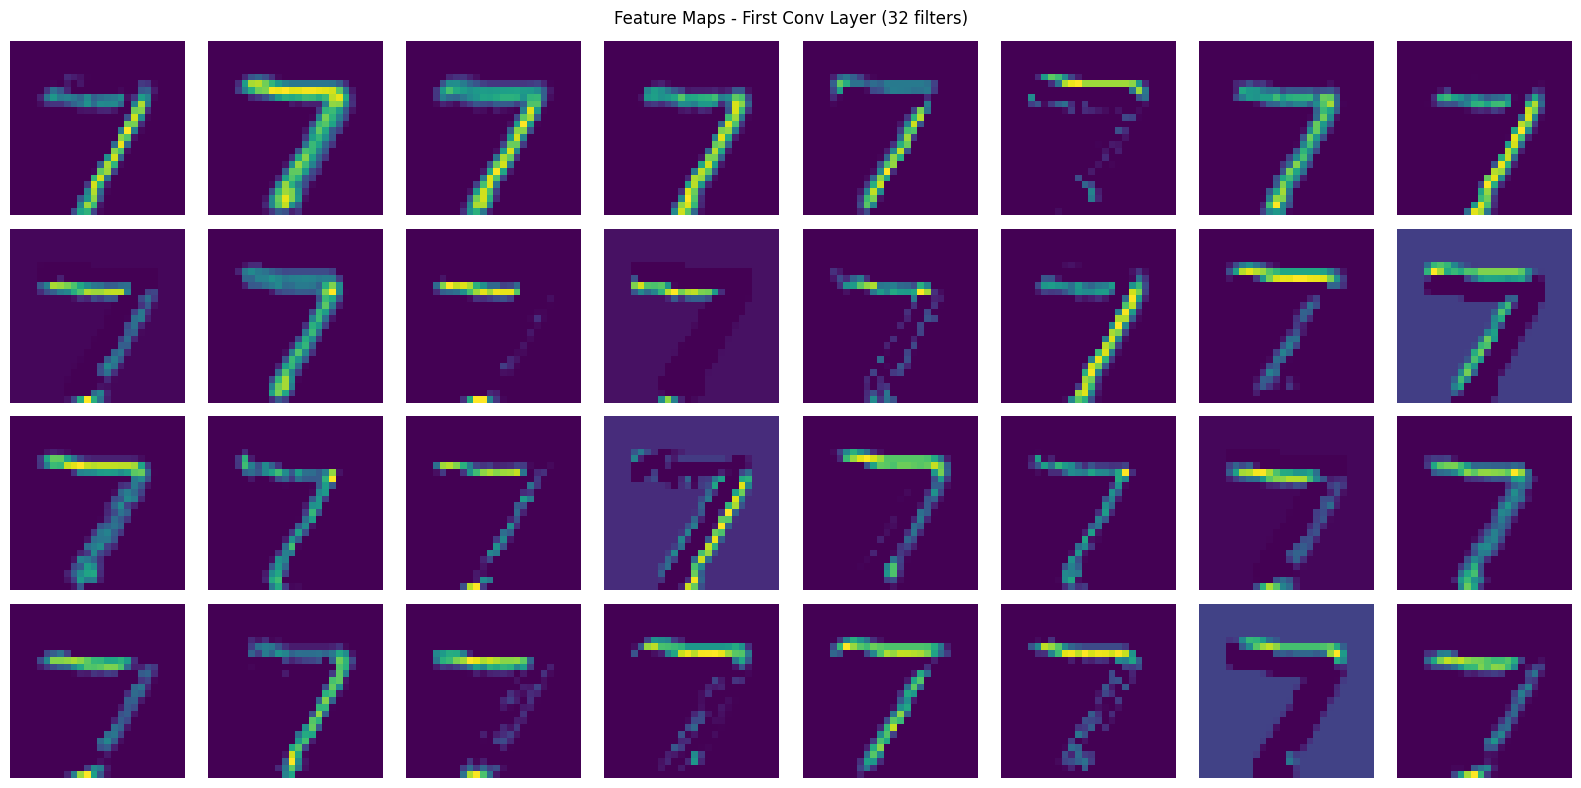

In [8]:
# Visualize feature maps from first Conv layer
from tensorflow.keras.layers import Input

feature_extractor_input = Input(shape=cnn.input_shape[1:]) # cnn.input_shape[0] is batch size (None)

# Apply the first Conv2D layer of the original CNN to this new input tensor
# This ensures that the output tensor is correctly linked to feature_extractor_input
output_of_first_conv_layer = cnn.layers[0](feature_extractor_input)

# Construct the feature model using the new input and the derived output
feature_model = Model(inputs=feature_extractor_input, outputs=output_of_first_conv_layer)

sample = X_test[0:1]
feature_maps = feature_model.predict(sample)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i < feature_maps.shape[-1]:
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
    ax.axis('off')
plt.suptitle('Feature Maps - First Conv Layer (32 filters)')
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


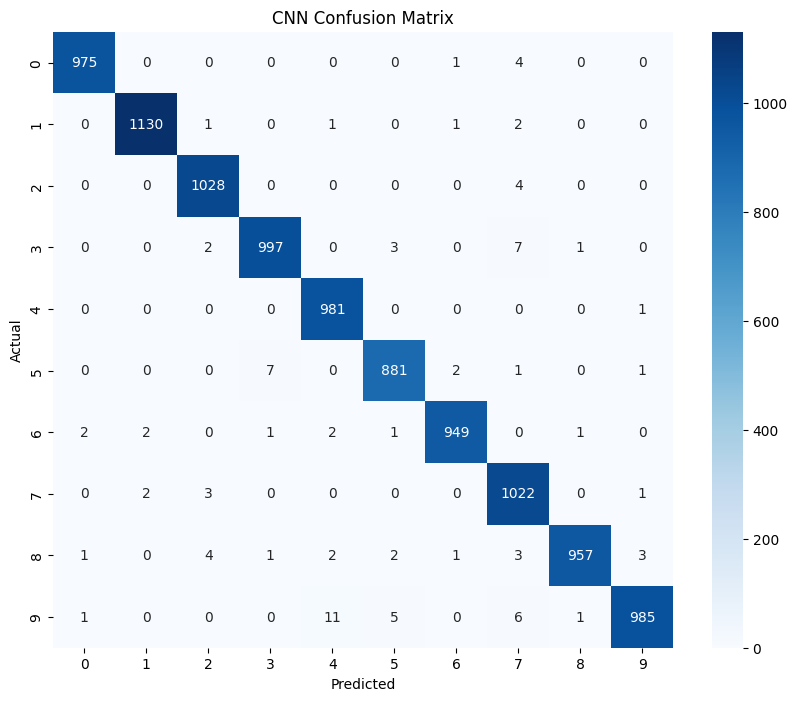

In [9]:
y_pred = np.argmax(cnn.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [10]:
plt.savefig("plot.png")

<Figure size 640x480 with 0 Axes>